# Practical Implementation of Linear Regreesion model

In [36]:
import pandas as pd
import numpy as npa
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing

In [37]:
df=fetch_california_housing()

In [38]:
df

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

In [39]:
data=pd.DataFrame(df.data)

In [43]:
data

,0,1,2,3,4,5,6,7
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


created dataframe with actual column names 

In [50]:
data.columns=df.feature_names

In [51]:
data.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [53]:
data['Price']=df.target

In [54]:
data

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [121]:
#dependent and independent features
X = pd.DataFrame(df.data, columns=df.feature_names)
y = df.target

In [122]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42
)

In [ ]:
## standarzing the dataset

In [123]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit and transform the training data, then convert back to DataFrame
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), 
    columns=X_train.columns
)

# ONLY transform the test data (never fit on test data!)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), 
    columns=X_test.columns
)

In [124]:
X_train_scaled

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,-1.521700,-0.758685,-0.918131,0.072769,-0.614962,-0.040150,-0.783153,0.650904
1,0.182054,0.352399,0.307485,-0.024416,-0.362823,-0.059436,0.847598,-1.319117
2,-0.172328,1.066667,-0.251078,-0.004705,-0.337522,0.095154,-0.872188,0.660879
3,-1.171732,-0.361869,-0.474558,-0.110273,0.222592,0.110994,0.102513,0.162139
4,0.059986,-1.155500,-0.338151,-0.018360,1.140412,-0.051997,0.885086,-1.184457
...,...,...,...,...,...,...,...,...
13823,1.310147,0.511125,0.282717,-0.384285,-0.674288,-0.007623,-0.876874,0.810501
13824,-0.434436,0.352399,0.584660,0.385833,0.281047,0.061331,-0.764409,1.074833
13825,-0.495181,0.590488,-0.591926,-0.040021,0.283664,0.016085,-0.759723,0.601030
13826,0.968167,-1.076137,0.391447,-0.066314,0.301985,0.003972,0.903830,-1.184457


In [125]:
X_test_scaled

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,-1.153708,-0.282506,-0.508033,-0.168843,-0.033909,0.059212,0.191548,0.286824
1,-0.707000,0.114310,-0.162154,0.215316,0.117026,-0.035496,-0.239569,0.062391
2,-0.208428,1.860298,-0.595830,0.198228,-0.105450,-0.139837,1.006924,-1.423852
3,0.977836,-0.917411,0.296845,-0.173515,0.239169,0.024972,-0.642571,0.431459
4,-0.079739,0.431762,0.023041,-0.155934,-0.320945,-0.051007,0.453968,-1.169495
...,...,...,...,...,...,...,...,...
6807,-1.339885,-0.758685,-0.591575,0.124927,-0.210144,-0.052579,-1.148666,1.109744
6808,-0.599383,-1.155500,-0.502150,-0.255932,-0.180481,0.019235,-1.443888,1.254379
6809,-0.021674,-1.076137,0.401410,-0.129584,1.042697,0.037446,1.433356,-0.905163
6810,0.272751,-1.472953,0.293118,-0.187546,1.829649,0.051935,-0.731606,1.094782


In [126]:
from sklearn.linear_model import LinearRegression

regression = LinearRegression()
regression.fit(X_train_scaled, y_train)

LinearRegression()

In [128]:
from sklearn.metrics import r2_score
import seaborn as sns

pred = regression.predict(X_test_scaled)
pred

array([0.72563462, 1.76650223, 2.70545812, ..., 1.25803135, 1.66673014,
       2.25826279])

In [131]:
r2 = r2_score(y_test, pred)
print('R2 is:',r2)

R2 is: 0.5970494128783952


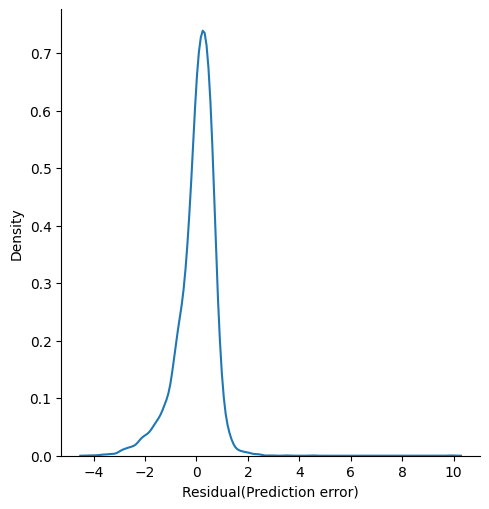

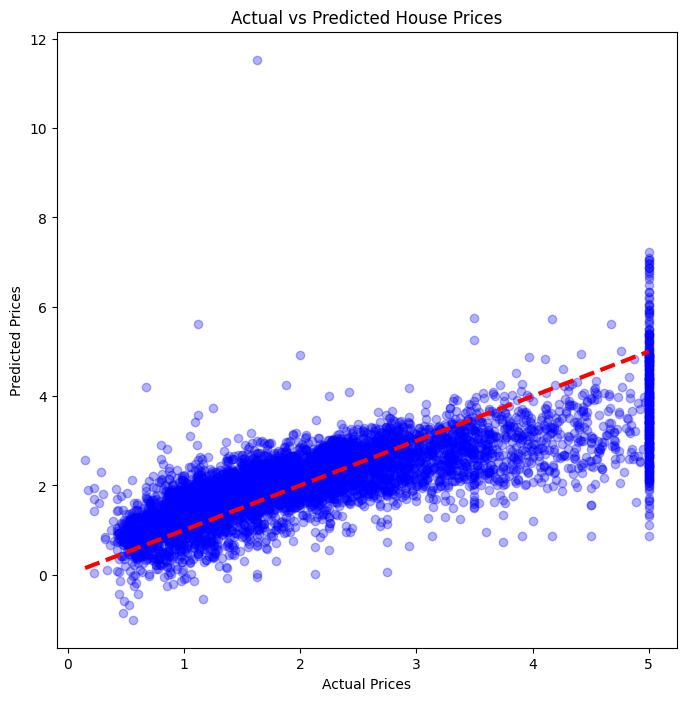

In [136]:
sns.displot(pred-y_test, kind='kde')
plt.xlabel("Residual(Prediction error)")
plt.figure(figsize=(8, 8))
plt.scatter(y_test, pred, alpha=0.3, color='blue')
# Draw a perfect prediction diagonal line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=3)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted House Prices')
plt.show()

C:\Users\suraj madane\AppData\Local\Temp\ipykernel_15720\738971836.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=coefficients, palette='viridis')


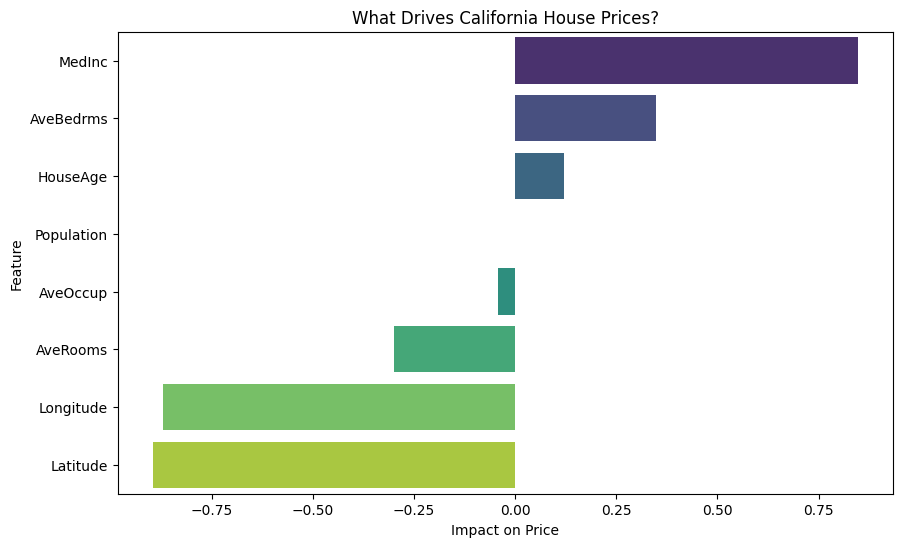

In [135]:
# Get the coefficients from the trained model
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Importance': regression.coef_
}).sort_values(by='Importance', ascending=False)

# Plot them
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=coefficients, palette='viridis')
plt.title('What Drives California House Prices?')
plt.xlabel('Impact on Price')
plt.show()

#### Did you know Median Income is the biggest driver of house prices in this dataset, while the age of the house barely matters?